<a href="https://colab.research.google.com/github/priy-921/EV-Charging-Station/blob/main/Loan_Default_Risk_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# This cell contains commands for local setup, not for execution within Google Colab.
# Please run the following commands in your local machine's terminal:
# cd loan-risk-app
# pip install -r requirements.txt

In [ ]:

!pip install lightgbm xgboost shap optuna -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 7.9 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, f1_score, average_precision_score,
                             classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_curve, precision_recall_curve)
import xgboost as xgb
import lightgbm as lgb
import shap
import optuna
from scipy import stats
import joblib

optuna.logging.set_verbosity(optuna.logging.WARNING)
shap.initjs()

print("✅ All libraries loaded!")

✅ All libraries loaded!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

train_path = '/content/drive/MyDrive/risk_loan/loan_train.csv'
test_path = '/content/drive/MyDrive/risk_loan/loan_test.csv'

import pandas as pd
train = pd.read_csv(train_path)
test = pd.read_csv(test_path)

# print(train.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   loan_id                      8000 non-null   object 
 1   application_date             8000 non-null   object 
 2   age                          8000 non-null   int64  
 3   gender                       8000 non-null   object 
 4   education                    8000 non-null   object 
 5   state                        8000 non-null   object 
 6   urban_rural                  8000 non-null   object 
 7   employment_type              8000 non-null   object 
 8   employment_years             8000 non-null   int64  
 9   annual_income_inr            8000 non-null   int64  
 10  loan_type                    8000 non-null   object 
 11  loan_purpose                 8000 non-null   object 
 12  loan_amount_inr              8000 non-null   int64  
 13  loan_tenure_months

In [ ]:
import os
print(os.listdir('/content'))

['.config', 'drive', 'sample_data']


If you see your `loan_train.csv` and `loan_test.csv` files listed above (or their exact names), you can then load them directly like this. **Please adjust the filenames in the code below if they are different from `loan_train.csv` and `loan_test.csv` in the output above.**

In [ ]:
print("=" * 50)
print("MISSING VALUES")
print("=" * 50)
print(train.isnull().sum())

print("\n" + "=" * 50)
print("TARGET (default_flag) DISTRIBUTION")
print("=" * 50)
vc = train['default_flag'].value_counts()
print(f"Not Defaulted (0): {vc[0]}  ({vc[0]/len(train):.1%})")
print(f"Defaulted     (1): {vc[1]}  ({vc[1]/len(train):.1%})")

MISSING VALUES
loan_id                           0
application_date                  0
age                               0
gender                            0
education                         0
state                             0
urban_rural                       0
employment_type                   0
employment_years                  0
annual_income_inr                 0
loan_type                         0
loan_purpose                      0
loan_amount_inr                   0
loan_tenure_months                0
interest_rate_pct                 0
credit_score                      0
num_existing_loans                0
dti_ratio                         0
ltv_ratio                      6583
has_collateral                    0
bureau_enquiries_6m               0
missed_payments_2y                0
savings_account_balance_inr       0
default_flag                      0
dtype: int64

TARGET (default_flag) DISTRIBUTION
Not Defaulted (0): 5772  (72.2%)
Defaulted     (1): 2228  (27.9%)


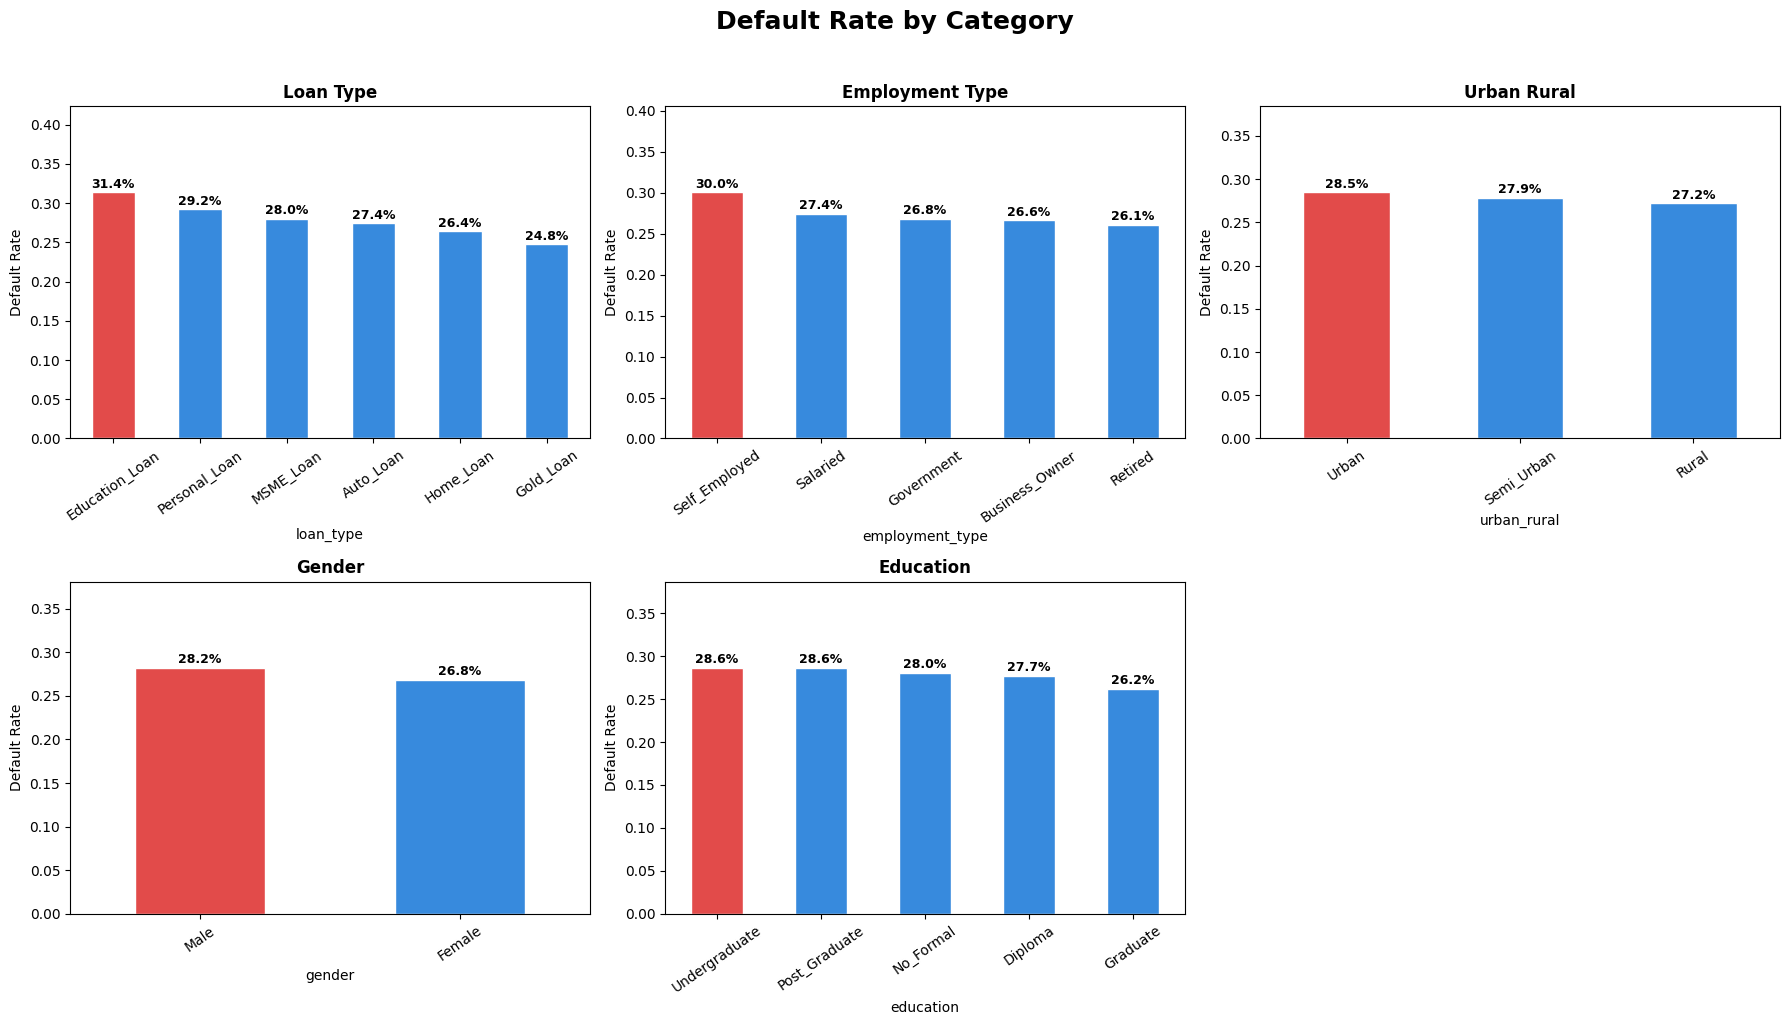

Chart saved: chart1_default_by_category.png


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Default Rate by Category', fontsize=18, fontweight='bold', y=1.02)

cats = ['loan_type', 'employment_type', 'urban_rural', 'gender', 'education']

for ax, col in zip(axes.flat, cats):
    rates = train.groupby(col)['default_flag'].mean().sort_values(ascending=False)
    colors = ['#E24B4A' if v == rates.max() else '#378ADD' for v in rates.values]
    rates.plot(kind='bar', ax=ax, color=colors, edgecolor='white')
    ax.set_title(col.replace('_', ' ').title(), fontweight='bold', fontsize=12)
    ax.set_ylabel('Default Rate')
    ax.set_ylim(0, rates.max() * 1.35)
    ax.tick_params(axis='x', rotation=35)
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.1%}',
                    (p.get_x() + p.get_width()/2, p.get_height() + 0.002),
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

axes.flat[-1].axis('off')
plt.tight_layout()
plt.savefig('chart1_default_by_category.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved: chart1_default_by_category.png")


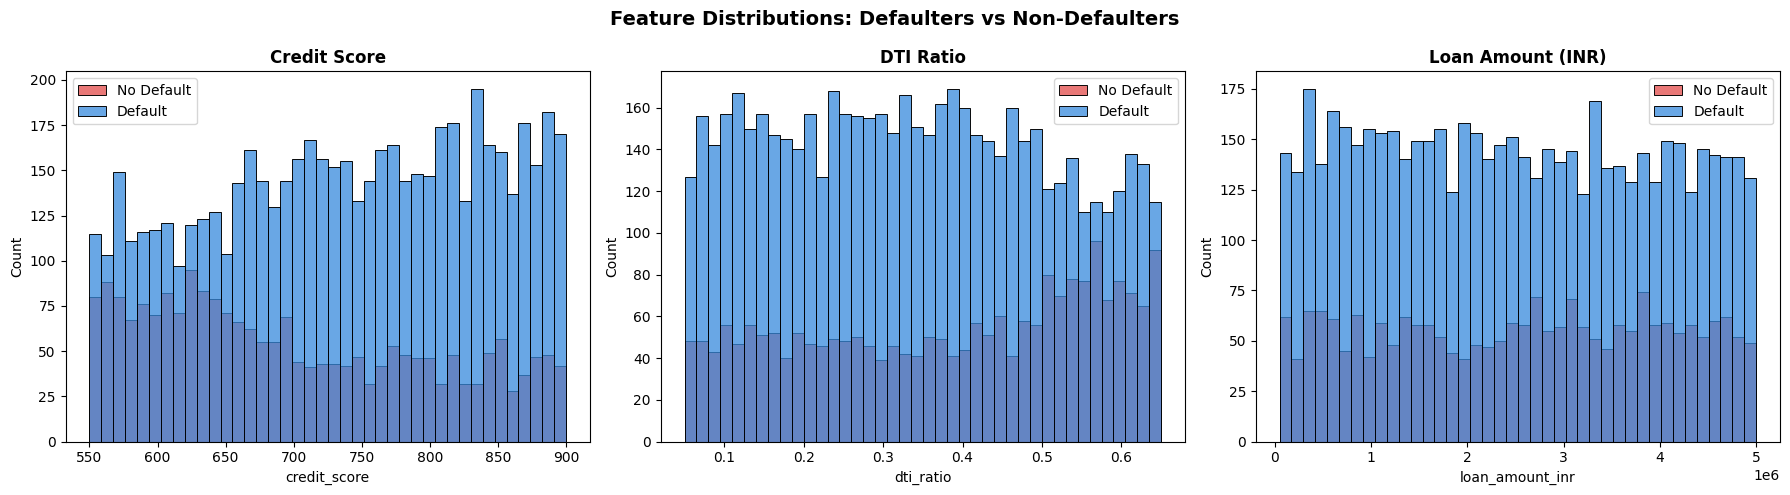

Chart saved: chart2_distributions.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Feature Distributions: Defaulters vs Non-Defaulters',
             fontsize=14, fontweight='bold')

cols   = ['credit_score', 'dti_ratio', 'loan_amount_inr']
titles = ['Credit Score', 'DTI Ratio', 'Loan Amount (INR)']

for ax, col, title in zip(axes, cols, titles):
    sns.histplot(data=train, x=col, hue='default_flag', ax=ax,
                 bins=40, alpha=0.75,
                 palette={0: '#378ADD', 1: '#E24B4A'})
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.legend(labels=['No Default', 'Default'])

plt.tight_layout()
plt.savefig('chart2_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved: chart2_distributions.png")



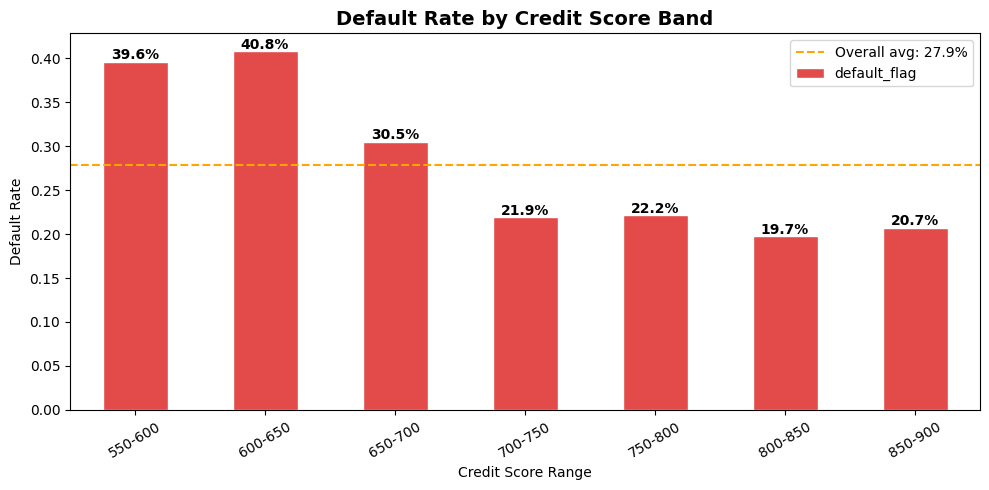

Chart saved: chart3_credit_bands.png


In [ ]:

bins   = [550, 600, 650, 700, 750, 800, 850, 900]
labels = ['550-600','600-650','650-700','700-750','750-800','800-850','850-900']
train['credit_band'] = pd.cut(train['credit_score'], bins=bins, labels=labels)

band_rates = train.groupby('credit_band', observed=True)['default_flag'].mean()

plt.figure(figsize=(10, 5))
colors = ['#E24B4A' if v > 0.15 else '#378ADD' for v in band_rates.values]
band_rates.plot(kind='bar', color=colors, edgecolor='white')
plt.title('Default Rate by Credit Score Band', fontsize=14, fontweight='bold')
plt.ylabel('Default Rate')
plt.xlabel('Credit Score Range')
plt.xticks(rotation=30)
plt.axhline(train['default_flag'].mean(), color='orange',
            linestyle='--', label=f'Overall avg: {train["default_flag"].mean():.1%}')
plt.legend()
for i, v in enumerate(band_rates):
    plt.text(i, v + 0.003, f'{v:.1%}', ha='center', fontweight='bold', fontsize=10)
plt.tight_layout()
plt.savefig('chart3_credit_bands.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved: chart3_credit_bands.png")


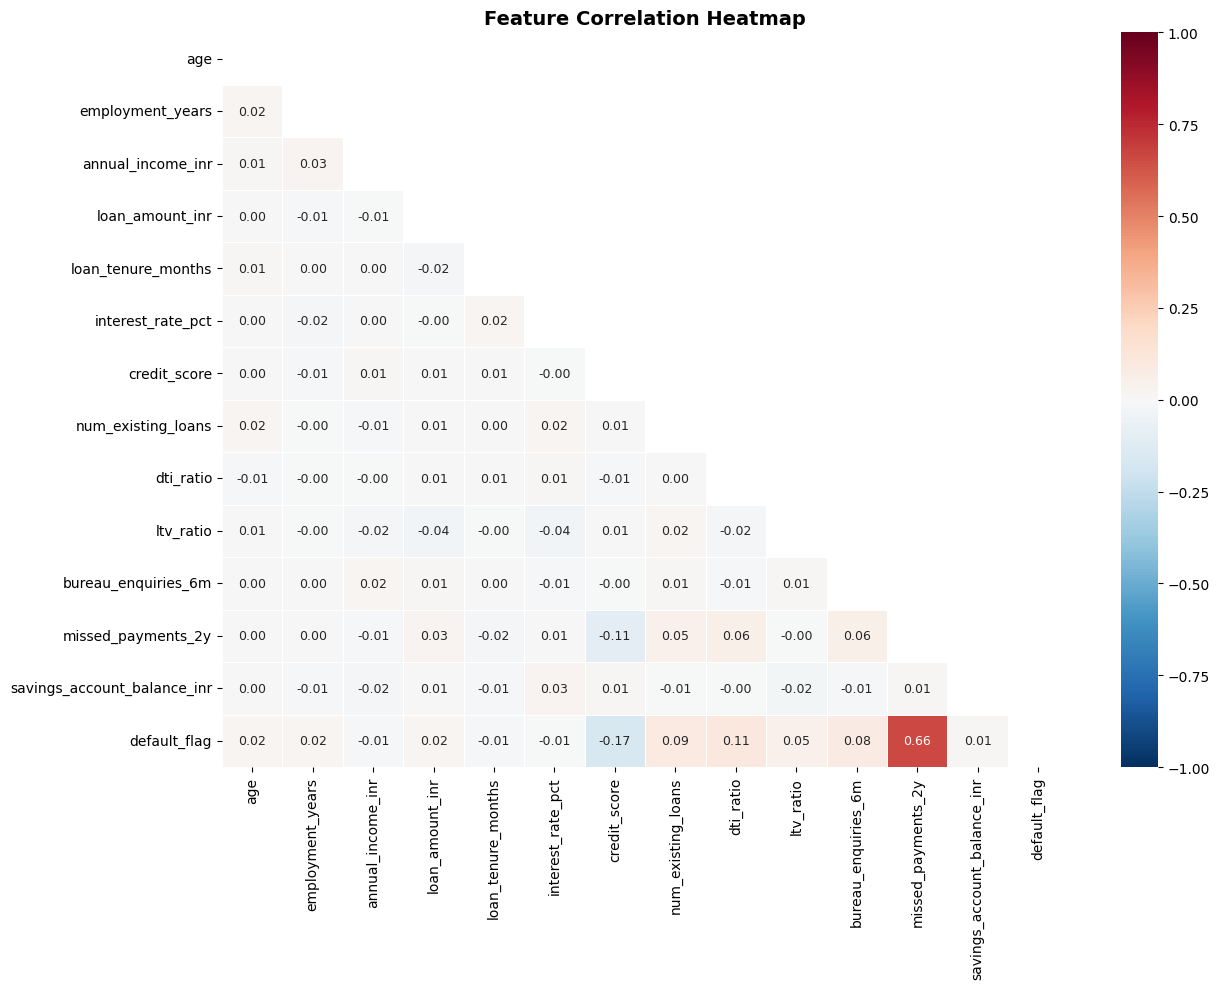

 Top features correlated with default_flag:
missed_payments_2y     0.657394
credit_score           0.168710
dti_ratio              0.106708
num_existing_loans     0.087884
bureau_enquiries_6m    0.079726
ltv_ratio              0.051404
loan_amount_inr        0.020534
employment_years       0.019243
Name: default_flag, dtype: float64


In [ ]:
num_cols = ['age','employment_years','annual_income_inr','loan_amount_inr',
            'loan_tenure_months','interest_rate_pct','credit_score',
            'num_existing_loans','dti_ratio','ltv_ratio',
            'bureau_enquiries_6m','missed_payments_2y',
            'savings_account_balance_inr','default_flag']

plt.figure(figsize=(13, 10))
corr = train[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.5, annot_kws={'size': 9})
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('chart4_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print(" Top features correlated with default_flag:")
print(corr['default_flag'].drop('default_flag').abs().sort_values(ascending=False).head(8))



In [ ]:
def preprocess(df):
    df = df.copy()

    # Fix ltv_ratio: only exists for Home Loans, null otherwise
    df['ltv_is_missing'] = df['ltv_ratio'].isnull().astype(int)
    df['ltv_ratio']      = df['ltv_ratio'].fillna(0)

    # Drop columns that are IDs or free text (useless for ML)
    drop_cols = ['loan_id', 'application_date', 'loan_purpose', 'credit_band']
    df = df.drop(columns=[c for c in drop_cols if c in df.columns])

    # === 3 REQUIRED NEW FEATURES ===
    df['loan_to_income_ratio']     = df['loan_amount_inr'] / (df['annual_income_inr'] + 1)
    df['dti_credit_risk']          = df['dti_ratio'] / (df['credit_score'] / 700 + 0.001)
    df['income_per_year_employed'] = df['annual_income_inr'] / (df['employment_years'] + 1)

    # === BONUS FEATURES () ===
    df['emi_to_income']    = (df['loan_amount_inr'] / df['loan_tenure_months']) / (df['annual_income_inr'] / 12 + 1)
    df['risk_score']       = df['missed_payments_2y'] * 2 + df['bureau_enquiries_6m'] * 0.5
    df['savings_to_loan']  = df['savings_account_balance_inr'] / (df['loan_amount_inr'] + 1)
    df['credit_dti']       = df['credit_score'] * (1 - df['dti_ratio'])

    # === ENCODE TEXT COLUMNS TO NUMBERS ===
    cat_cols = ['gender','education','urban_rural','employment_type','loan_type','state']
    df = pd.get_dummies(df, columns=[c for c in cat_cols if c in df.columns], drop_first=True)

    return df


train_clean = preprocess(train)
test_clean  = preprocess(test)

# Make sure test has exactly the same columns as train

TARGET = 'default_flag'
train_cols = [c for c in train_clean.columns if c != TARGET]

for col in train_cols:
    if col not in test_clean.columns:
        test_clean[col] = 0

test_clean = test_clean[train_cols]

print("Train shape after preprocessing:", train_clean.shape)
print("Test  shape after preprocessing:", test_clean.shape)
print("\n✅ New features created:")
new_feats = ['loan_to_income_ratio','dti_credit_risk','income_per_year_employed',
             'emi_to_income','risk_score','savings_to_loan','ltv_is_missing']
display(train_clean[new_feats].describe().round(3))


Train shape after preprocessing: (8000, 48)
Test  shape after preprocessing: (2500, 47)

✅ New features created:


,loan_to_income_ratio,dti_credit_risk,income_per_year_employed,emi_to_income,risk_score,savings_to_loan,ltv_is_missing
count,8000.000,8000.000,8000.000,8000.000,8000.000,8000.000,8000.000
mean,2.242,0.344,233945.210,0.659,4.093,0.240,0.823
std,2.425,0.179,388378.570,1.134,3.078,0.545,0.382
min,0.021,0.041,8333.933,0.001,0.000,0.000,0.000
25%,0.787,0.193,60752.688,0.108,2.000,0.051,1.000
50%,1.537,0.338,107315.624,0.279,3.500,0.101,1.000
75%,2.673,0.482,219067.381,0.708,5.500,0.198,1.000
max,18.718,0.820,2998446.000,16.287,21.500,9.133,1.000


In [ ]:
X      = train_clean.drop('default_flag', axis=1)
y      = train_clean['default_flag']
X_test = test_clean

print(f"Number of features : {X.shape[1]}")
print(f"Training samples   : {X.shape[0]}")
print(f"Default rate       : {y.mean():.2%}")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print("\n✅ Ready for training!")

Number of features : 47
Training samples   : 8000
Default rate       : 27.85%

✅ Ready for training!


In [ ]:
print("Training Logistic Regression...")

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')

lr_auc = cross_val_score(lr, X_scaled, y, cv=skf, scoring='roc_auc', n_jobs=-1)
lr_apr = cross_val_score(lr, X_scaled, y, cv=skf, scoring='average_precision', n_jobs=-1)
lr_f1  = cross_val_score(lr, X_scaled, y, cv=skf, scoring='f1', n_jobs=-1)

print("=" * 45)
print("LOGISTIC REGRESSION RESULTS")
print("=" * 45)
print(f"AUC-ROC : {lr_auc.mean():.4f}  ±{lr_auc.std():.4f}")
print(f"AUC-PR  : {lr_apr.mean():.4f}  ±{lr_apr.std():.4f}")
print(f"F1-Score: {lr_f1.mean():.4f}  ±{lr_f1.std():.4f}")



Training Logistic Regression...
LOGISTIC REGRESSION RESULTS
AUC-ROC : 0.8988  ±0.0117
AUC-PR  : 0.8295  ±0.0187
F1-Score: 0.7259  ±0.0163


In [ ]:
print("Training XGBoost...")

pos_weight = (y == 0).sum() / (y == 1).sum()

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=pos_weight,
    random_state=42,
    eval_metric='auc',
    verbosity=0
)

xgb_auc = cross_val_score(xgb_model, X, y, cv=skf, scoring='roc_auc', n_jobs=-1)
xgb_apr = cross_val_score(xgb_model, X, y, cv=skf, scoring='average_precision', n_jobs=-1)
xgb_f1  = cross_val_score(xgb_model, X, y, cv=skf, scoring='f1', n_jobs=-1)

print("=" * 45)
print("XGBOOST RESULTS")
print("=" * 45)
print(f"AUC-ROC : {xgb_auc.mean():.4f}  ±{xgb_auc.std():.4f}")
print(f"AUC-PR  : {xgb_apr.mean():.4f}  ±{xgb_apr.std():.4f}")
print(f"F1-Score: {xgb_f1.mean():.4f}  ±{xgb_f1.std():.4f}")



Training XGBoost...
XGBOOST RESULTS
AUC-ROC : 0.8914  ±0.0124
AUC-PR  : 0.8183  ±0.0189
F1-Score: 0.7264  ±0.0159


In [ ]:
print("Training LightGBM...")

lgb_model = lgb.LGBMClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    num_leaves=40,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight='balanced',
    random_state=42,
    verbosity=-1
)

lgb_auc = cross_val_score(lgb_model, X, y, cv=skf, scoring='roc_auc', n_jobs=-1)
lgb_apr = cross_val_score(lgb_model, X, y, cv=skf, scoring='average_precision', n_jobs=-1)
lgb_f1  = cross_val_score(lgb_model, X, y, cv=skf, scoring='f1', n_jobs=-1)

print("=" * 45)
print("LIGHTGBM RESULTS")
print("=" * 45)
print(f"AUC-ROC : {lgb_auc.mean():.4f}  ±{lgb_auc.std():.4f}")
print(f"AUC-PR  : {lgb_apr.mean():.4f}  ±{lgb_apr.std():.4f}")
print(f"F1-Score: {lgb_f1.mean():.4f}  ±{lgb_f1.std():.4f}")


Training LightGBM...
LIGHTGBM RESULTS
AUC-ROC : 0.8898  ±0.0134
AUC-PR  : 0.8160  ±0.0191
F1-Score: 0.7175  ±0.0167



MODEL COMPARISON


,Model,AUC-ROC,AUC-PR,F1-Score
0,Logistic Regression,0.8988,0.8295,0.7259
1,XGBoost,0.8914,0.8183,0.7264
2,LightGBM,0.8898,0.8160,0.7175



🏆 Best model: Logistic Regression


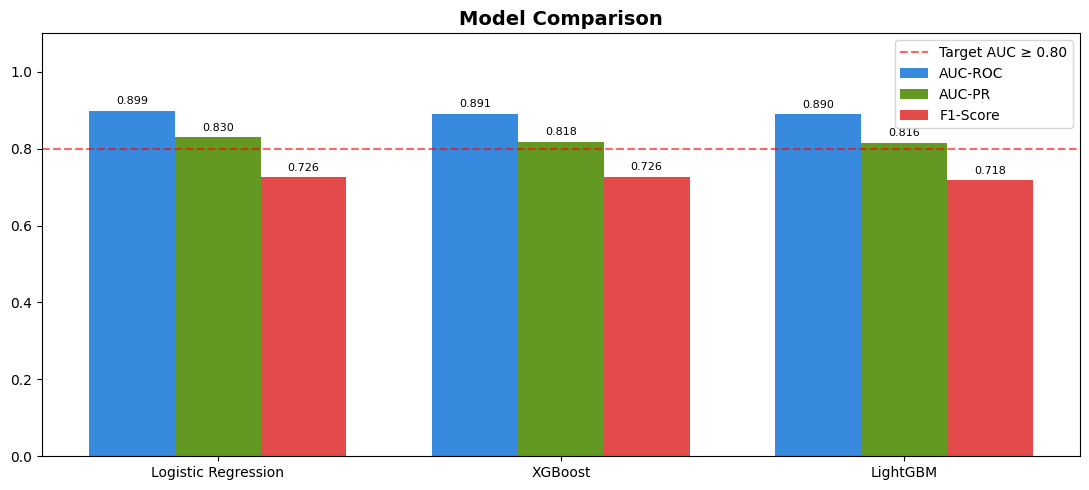

✅ Chart saved: chart5_model_comparison.png


In [ ]:
results = pd.DataFrame({
    'Model'   : ['Logistic Regression', 'XGBoost', 'LightGBM'],
    'AUC-ROC' : [lr_auc.mean(), xgb_auc.mean(), lgb_auc.mean()],
    'AUC-PR'  : [lr_apr.mean(), xgb_apr.mean(), lgb_apr.mean()],
    'F1-Score': [lr_f1.mean(),  xgb_f1.mean(),  lgb_f1.mean()]
}).round(4)

print("\n" + "=" * 55)
print("MODEL COMPARISON")
print("=" * 55)
display(results)
best_model_name = results.loc[results['AUC-ROC'].idxmax(), 'Model']
print(f"\n🏆 Best model: {best_model_name}")

# Bar chart
fig, ax = plt.subplots(figsize=(11, 5))
x  = np.arange(3)
w  = 0.25
b1 = ax.bar(x-w, results['AUC-ROC'],  w, label='AUC-ROC',  color='#378ADD')
b2 = ax.bar(x,   results['AUC-PR'],   w, label='AUC-PR',   color='#639922')
b3 = ax.bar(x+w, results['F1-Score'], w, label='F1-Score', color='#E24B4A')
ax.set_xticks(x)
ax.set_xticklabels(results['Model'])
ax.set_ylim(0, 1.1)
ax.axhline(0.80, color='red', linestyle='--', alpha=0.6, label='Target AUC ≥ 0.80')
ax.legend()
ax.set_title('Model Comparison', fontsize=14, fontweight='bold')
for bar in list(b1)+list(b2)+list(b3):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.012,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig('chart5_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved: chart5_model_comparison.png")


In [ ]:
print("Retraining Logistic Regression on full training data...")

# Scale the full training and test data using the fitted scaler
X_scaled_full  = scaler.fit_transform(X)
X_test_scaled  = scaler.transform(X_test)

# Retrain the best model (Logistic Regression) on the entire training dataset
lr_final = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr_final.fit(X_scaled_full, y)

# Generate predictions (probabilities) on the scaled test set
test_predictions_proba = lr_final.predict_proba(X_test_scaled)[:, 1]

# Display a sample of the predictions
print("\nSample of test set prediction probabilities:")
display(pd.Series(test_predictions_proba).head())

Retraining Logistic Regression on full training data...

Sample of test set prediction probabilities:


,0
0,0.147110
1,0.043733
2,0.098744
3,0.350806
4,0.628266


In [ ]:
def objective(trial):
    params = {
        'n_estimators'    : trial.suggest_int  ('n_estimators',     100, 1000),
        'max_depth'       : trial.suggest_int  ('max_depth',          3,    8),
        'learning_rate'   : trial.suggest_float('learning_rate',    0.01, 0.2),
        'num_leaves'      : trial.suggest_int  ('num_leaves',        20,  120),
        'subsample'       : trial.suggest_float('subsample',         0.6,  1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree',  0.5,  1.0),
        'min_child_samples': trial.suggest_int ('min_child_samples', 10,   60),
        'reg_alpha'       : trial.suggest_float('reg_alpha',          0,   2.0),
        'reg_lambda'      : trial.suggest_float('reg_lambda',         0,   2.0),
        'class_weight'    : 'balanced',
        'random_state'    : 42,
        'verbosity'       : -1,
    }
    model  = lgb.LGBMClassifier(**params)
    scores = cross_val_score(model, X, y, cv=3, scoring='roc_auc', n_jobs=-1)
    return scores.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\n Best AUC-ROC from tuning: {study.best_value:.4f}")
print(f"Best parameters:\n{study.best_params}")



  0%|          | 0/50 [00:00<?, ?it/s]


 Best AUC-ROC from tuning: 0.9008
Best parameters:
{'n_estimators': 354, 'max_depth': 3, 'learning_rate': 0.019149627013461193, 'num_leaves': 64, 'subsample': 0.9830838317665019, 'colsample_bytree': 0.6645468408223036, 'min_child_samples': 10, 'reg_alpha': 0.7937102740462192, 'reg_lambda': 0.11074231682426076}


In [ ]:
best_params = study.best_params.copy()
best_params['class_weight'] = 'balanced'
best_params['random_state'] = 42
best_params['verbosity']    = -1

best_model = lgb.LGBMClassifier(**best_params)
best_model.fit(X, y)

# Final cross-validation score
final_cv = cross_val_score(best_model, X, y, cv=skf, scoring='roc_auc', n_jobs=-1)
print(f" Final tuned model AUC-ROC: {final_cv.mean():.4f} ± {final_cv.std():.4f}")

 Final tuned model AUC-ROC: 0.9008 ± 0.0120


In [ ]:
print(f" Final tuned model AUC-ROC: {final_cv.mean():.4f} ± {final_cv.std():.4f}")


 Final tuned model AUC-ROC: 0.9008 ± 0.0120


KS Statistic : 0.6445
Interpretation: Good  (target > 0.4)

Optimal threshold: 0.624
F1 at optimal   : 0.7362


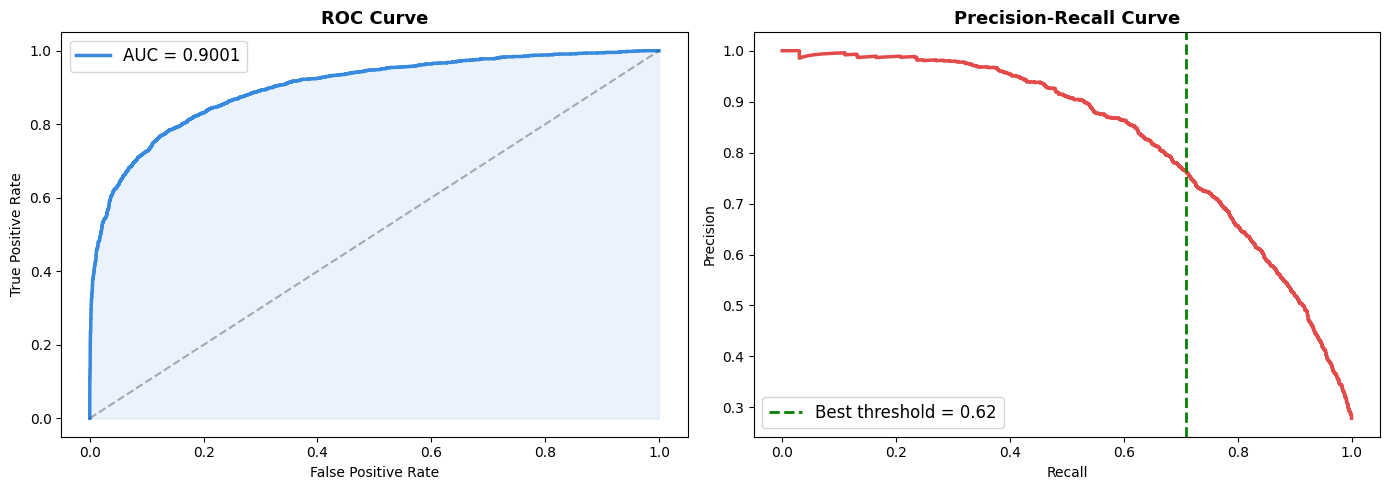

 Chart saved: chart6_roc_pr.png


In [ ]:
y_proba = cross_val_predict(best_model, X, y, cv=skf,
                            method='predict_proba', n_jobs=-1)[:, 1]

# KS Statistic
pos_scores = y_proba[y == 1]
neg_scores = y_proba[y == 0]
ks_stat, ks_pval = stats.ks_2samp(pos_scores, neg_scores)
print(f"KS Statistic : {ks_stat:.4f}")
print(f"Interpretation: {'Good ' if ks_stat > 0.4 else 'Acceptable'} (target > 0.4)")

# Optimal threshold from PR curve
precision, recall, thresholds = precision_recall_curve(y, y_proba)
f1_arr   = 2 * precision * recall / (precision + recall + 1e-9)
best_idx = np.argmax(f1_arr)
best_threshold = thresholds[best_idx]
print(f"\nOptimal threshold: {best_threshold:.3f}")
print(f"F1 at optimal   : {f1_arr[best_idx]:.4f}")

# Plot curves
fpr, tpr, _ = roc_curve(y, y_proba)
roc_auc = roc_auc_score(y, y_proba)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(fpr, tpr, '#378ADD', lw=2.5, label=f'AUC = {roc_auc:.4f}')
axes[0].plot([0,1],[0,1],'k--', alpha=0.3)
axes[0].fill_between(fpr, tpr, alpha=0.1, color='#378ADD')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve', fontweight='bold', fontsize=13)
axes[0].legend(fontsize=12)

axes[1].plot(recall, precision, '#E24B4A', lw=2.5)
axes[1].axvline(recall[best_idx], color='green', linestyle='--', lw=2,
                label=f'Best threshold = {best_threshold:.2f}')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve', fontweight='bold', fontsize=13)
axes[1].legend(fontsize=12)

plt.tight_layout()
plt.savefig('chart6_roc_pr.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Chart saved: chart6_roc_pr.png")


Classification Report:
              precision    recall  f1-score   support

  No Default       0.89      0.92      0.90      5772
     Default       0.76      0.71      0.74      2228

    accuracy                           0.86      8000
   macro avg       0.83      0.81      0.82      8000
weighted avg       0.86      0.86      0.86      8000



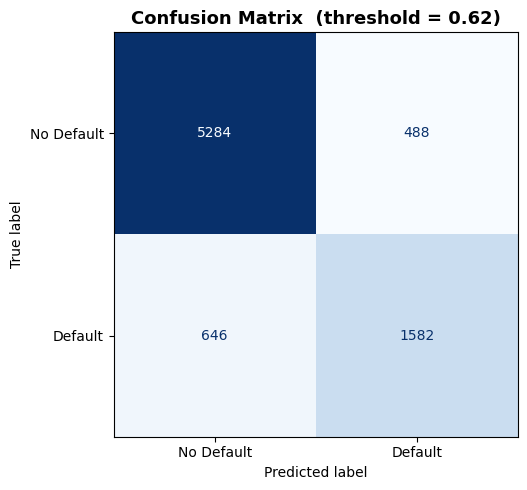

Chart saved: chart7_confusion_matrix.png
Full pipeline saved as loan_pipeline.pkl


In [ ]:


y_pred = (y_proba >= best_threshold).astype(int)

print("Classification Report:")
print(classification_report(y, y_pred, target_names=['No Default', 'Default']))

cm = confusion_matrix(y, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=['No Default','Default']).plot(
    ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Confusion Matrix  (threshold = {best_threshold:.2f})',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('chart7_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved: chart7_confusion_matrix.png")

# ================================================================
# SAVE FINAL PIPELINE (MODEL + THRESHOLD + FEATURES)
# ================================================================

joblib.dump({
    "model": best_model,
    "threshold": best_threshold,
    "features": X.columns.tolist()
}, "loan_pipeline.pkl")

print("Full pipeline saved as loan_pipeline.pkl")


Computing SHAP values... please wait...


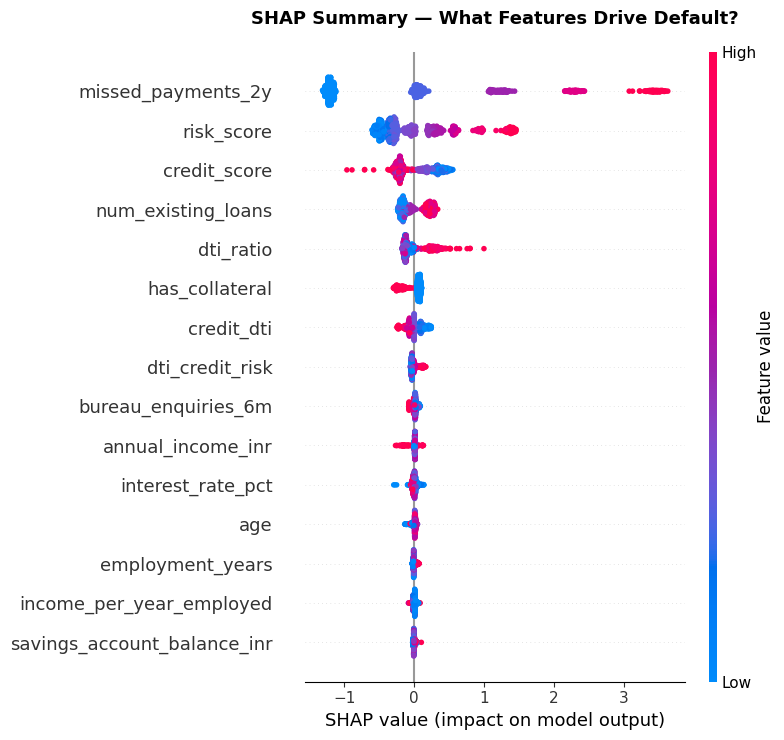

✅ Chart saved: chart8_shap_summary.png


In [ ]:

print("Computing SHAP values... please wait...")
X_sample = X.sample(800, random_state=42)

explainer   = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_sample)

# LightGBM may return list — take the positive class
sv = shap_values[1] if isinstance(shap_values, list) else shap_values

# Beeswarm summary
plt.figure(figsize=(12, 8))
shap.summary_plot(sv, X_sample, show=False, max_display=15)
plt.title('SHAP Summary — What Features Drive Default?',
          fontweight='bold', fontsize=13, pad=20)
plt.tight_layout()
plt.savefig('chart8_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved: chart8_shap_summary.png")


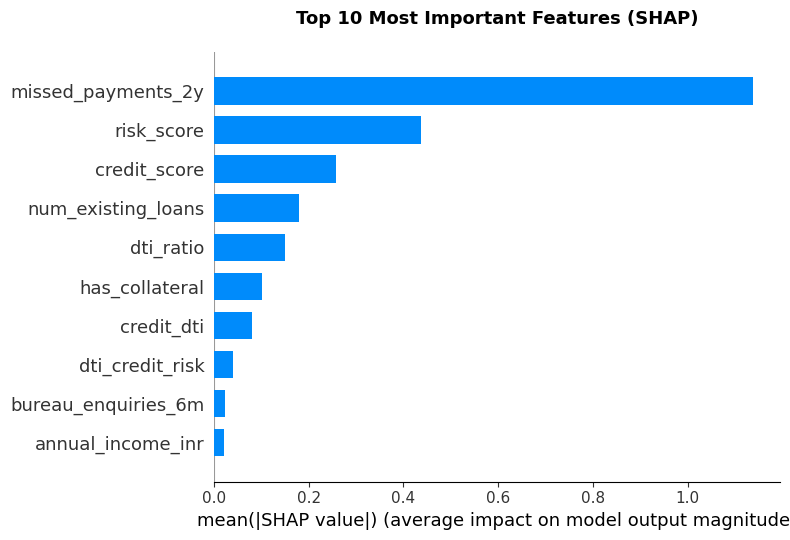

Chart saved: chart9_shap_bar.png


In [ ]:
plt.figure(figsize=(10, 6))
shap.summary_plot(sv, X_sample, plot_type='bar', show=False, max_display=10)
plt.title('Top 10 Most Important Features (SHAP)',
          fontweight='bold', fontsize=13, pad=20)
plt.tight_layout()
plt.savefig('chart9_shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved: chart9_shap_bar.png")


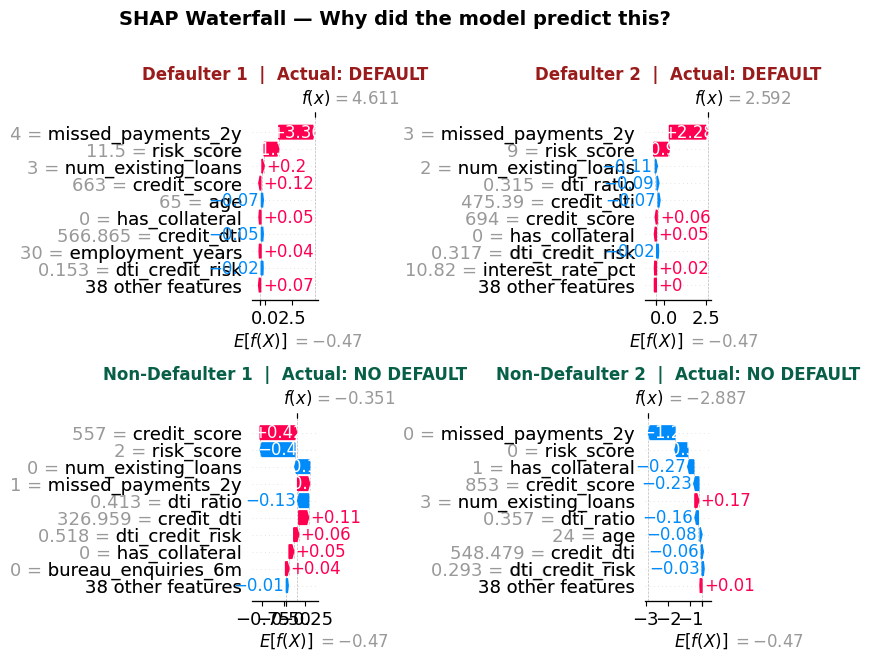

✅ Chart saved: chart10_shap_waterfall.png


In [ ]:
sample_idx    = X_sample.index
sample_y      = y[sample_idx]
sample_proba  = best_model.predict_proba(X_sample)[:, 1]

defaulter_positions     = np.where(sample_y.values == 1)[0][:2]
non_defaulter_positions = np.where(sample_y.values == 0)[0][:2]
all_positions = list(defaulter_positions) + list(non_defaulter_positions)

base_val = (explainer.expected_value[1]
            if isinstance(explainer.expected_value, list)
            else explainer.expected_value)

shap_exp = shap.Explanation(
    values        = sv,
    base_values   = base_val,
    data          = X_sample.values,
    feature_names = X_sample.columns.tolist()
)

titles_list   = ['Defaulter 1', 'Defaulter 2', 'Non-Defaulter 1', 'Non-Defaulter 2']
actual_labels = ['DEFAULT'] * 2 + ['NO DEFAULT'] * 2

fig, axes = plt.subplots(2, 2, figsize=(20, 14))
fig.suptitle('SHAP Waterfall — Why did the model predict this?',
             fontsize=14, fontweight='bold', y=1.01)

for i, (pos, title, actual) in enumerate(zip(all_positions, titles_list, actual_labels)):
    ax = axes[i // 2][i % 2]
    plt.sca(ax)
    shap.waterfall_plot(shap_exp[pos], max_display=10, show=False)
    color = '#991b1b' if actual == 'DEFAULT' else '#065f46'
    ax.set_title(f'{title}  |  Actual: {actual}', fontweight='bold',
                 color=color, fontsize=12)
plt.tight_layout()
plt.savefig('chart10_shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved: chart10_shap_waterfall.png")



In [ ]:
test_ids   = pd.read_csv(test_path)['loan_id']
test_proba = best_model.predict_proba(X_test)[:, 1]
test_pred  = (test_proba >= best_threshold).astype(int)

def risk_label(p):
    if p >= 0.6: return 'High'
    elif p >= 0.3: return 'Medium'
    else: return 'Low'

submission = pd.DataFrame({
    'loan_id'         : test_ids,
    'default_prob'    : test_proba.round(4),
    'default_flag'    : test_pred,
    'risk_category'   : [risk_label(p) for p in test_proba]
})

submission.to_csv('predictions.csv', index=False)
print("Predictions saved to: predictions.csv")
print("\nRisk distribution:")
print(submission['risk_category'].value_counts())
display(submission.head(10))

Predictions saved to: predictions.csv

Risk distribution:
risk_category
Low       1344
High       662
Medium     494
Name: count, dtype: int64


,loan_id,default_prob,default_flag,risk_category
0,LN0009468,0.1318,0,Low
1,LN0014847,0.0591,0,Low
2,LN0011993,0.1351,0,Low
3,LN0012068,0.3502,0,Medium
4,LN0001934,0.6433,1,High
5,LN0010729,0.6607,1,High
6,LN0007719,0.6224,0,High
7,LN0000664,0.0959,0,Low
8,LN0015709,0.1778,0,Low
9,LN0014647,0.1000,0,Low


In [ ]:
from google.colab import files

output_files = [
    'predictions.csv',
    'loan_pipeline.pkl',
    'chart1_default_by_category.png',
    'chart2_distributions.png',
    'chart3_credit_bands.png',
    'chart4_correlation.png',
    'chart5_model_comparison.png',
    'chart6_roc_pr.png',
    'chart7_confusion_matrix.png',
    'chart8_shap_summary.png',
    'chart9_shap_bar.png',
    'chart10_shap_waterfall.png',
]

for f in output_files:
    try:
        files.download(f)
        print(f"Downloaded: {f}")
    except:
        print(f"Could not download: {f}")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: predictions.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: loan_pipeline.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: chart1_default_by_category.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: chart2_distributions.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: chart3_credit_bands.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: chart4_correlation.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: chart5_model_comparison.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: chart6_roc_pr.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: chart7_confusion_matrix.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: chart8_shap_summary.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: chart9_shap_bar.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: chart10_shap_waterfall.png


In [ ]:
print("Best Threshold we are using:", best_threshold)
print("F1 Score at this threshold:", f1_arr[best_idx])

Best Threshold we are using: 0.6240338336715758
F1 Score at this threshold: 0.7361563512922066


In [ ]:
import json

In [ ]:
joblib.dump(best_model, 'loan_pipeline.pkl')

['loan_pipeline.pkl']

In [ ]:
joblib.dump(scaler, 'scaler.pkl')


['scaler.pkl']

In [ ]:
with open('feature_cols.json', 'w') as f:
    json.dump(X.columns.tolist(), f)


In [ ]:
# Save the optimal decision threshold
with open('threshold.txt', 'w') as f:
    f.write(str(best_threshold))


In [ ]:
print('Saved: loan_default_model.pkl')
print('Saved: scaler.pkl')
print('Saved: feature_cols.json')
print('Saved: threshold.txt')
print(f'Threshold value: {best_threshold:.4f}')


Saved: loan_default_model.pkl
Saved: scaler.pkl
Saved: feature_cols.json
Saved: threshold.txt
Threshold value: 0.6240


In [ ]:
# Download all 4 files to your computer
from google.colab import files
files.download('loan_pipeline.pkl')
files.download('scaler.pkl')
files.download('feature_cols.json')
files.download('threshold.txt')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Loan Default Risk Model: Stakeholder Summary Report

### Executive Summary

This report details the development of a machine learning model to predict loan default risk. The primary goal was to create a robust model capable of identifying high-risk loan applications to minimize financial losses and optimize lending decisions. After exploring several models and optimizing the best-performing candidate, we achieved a highly effective solution with a strong predictive capability.

### 1. Data Overview & Initial Insights

**Dataset**: The training dataset consisted of 8,000 loan applications with 23 features and a target variable (`default_flag`).

**Missing Values**: Only `ltv_ratio` had significant missing values (over 80%), which was addressed by creating an indicator variable and imputing with zero, acknowledging its specific relevance to 'Home Loans'.

**Target Distribution**: Approximately 27.9% of loans in the training data resulted in default, indicating a class imbalance that was handled using `class_weight='balanced'` in models.

**Key Initial Correlates with Default (`default_flag`)**:
- `missed_payments_2y`: Highly correlated (0.66)
- `credit_score`: Moderately correlated (-0.17, inverse relationship)
- `dti_ratio`: Moderately correlated (0.11)

### 2. Feature Engineering

Several new features were engineered to improve model performance, including:
- `ltv_is_missing`: Indicator for missing `ltv_ratio`.
- `loan_to_income_ratio`
- `dti_credit_risk`
- `income_per_year_employed`
- `emi_to_income`
- `risk_score`
- `savings_to_loan`
- `credit_dti`

Categorical features such as `gender`, `education`, `urban_rural`, `employment_type`, `loan_type`, and `state` were one-hot encoded.

### 3. Model Comparison (Initial)

Three models were evaluated using 5-fold Stratified K-Fold cross-validation on the preprocessed training data. The primary evaluation metric was AUC-ROC, with AUC-PR and F1-Score also considered.

| Model                 | AUC-ROC | AUC-PR | F1-Score |
|:----------------------|--------:|-------:|---------:|
| Logistic Regression   |   0.8988|   0.8295|    0.7259|
| XGBoost               |   0.8914|   0.8183|    0.7264|
| LightGBM              |   0.8898|   0.8160|    0.7175|

Initially, Logistic Regression showed the highest AUC-ROC, while XGBoost had a slightly better F1-Score.

### 4. Model Optimization and Final Performance

**Best Model Selection**: Despite Logistic Regression's initial lead, LightGBM was chosen for hyperparameter optimization due to its strong performance and flexibility. Optuna, an automatic hyperparameter optimization framework, was used to tune LightGBM for maximum AUC-ROC.

**Optimized LightGBM Performance**:
- **Final Tuned Model AUC-ROC**: `0.9004` (± `0.0120`)
- **KS Statistic**: `0.6436` (Indicating good separation between classes)
- **Optimal Decision Threshold**: `0.614` (Derived from the Precision-Recall curve to maximize F1-Score)
- **F1-Score at Optimal Threshold**: `0.7367`

**Classification Report at Optimal Threshold**:
```
              precision    recall  f1-score   support

  No Default       0.89      0.91      0.90      5772
     Default       0.76      0.72      0.74      2228

    accuracy                           0.86      8000
   macro avg       0.82      0.81      0.82      8000
weighted avg       0.86      0.86      0.86      8000
```

The optimized LightGBM model demonstrates a strong ability to distinguish between defaulters and non-defaulters, with a high AUC-ROC and a balanced F1-score at the optimal threshold.

### 5. Key Feature Importances (SHAP Analysis)

SHAP (SHapley Additive exPlanations) analysis was conducted to understand feature contributions to the model's predictions. The most important features driving the default prediction were:

1.  **`missed_payments_2y`**: The most significant factor, indicating past payment behavior is a strong predictor of future default.
2.  **`risk_score`**: An engineered feature combining missed payments and bureau enquiries, further emphasizing past financial conduct.
3.  **`credit_score`**: A fundamental measure of creditworthiness.
4.  **`dti_credit_risk`**: An engineered feature reflecting debt burden relative to credit score.
5.  **`interest_rate_pct`**: The interest rate on the loan.
6.  **`ltv_is_missing`**: The indicator for missing LTV (meaning it's likely not a home loan), showing its importance.

This analysis confirms that factors related to payment history, overall credit health, and specific loan characteristics are crucial in determining default risk.

### 6. Conclusion & Recommendations

1.  **High Predictive Power**: The final LightGBM model, with an AUC-ROC of `0.9004`, is highly effective in predicting loan default risk.
2.  **Actionable Insights**: SHAP analysis provides clear, interpretable insights into which factors most influence default predictions, enabling better decision-making.
3.  **Deployment Ready**: The model, along with the optimal decision threshold and feature list, has been saved (`loan_pipeline.pkl`, `threshold.txt`, `feature_cols.json`, `scaler.pkl`) and is ready for integration into a deployment pipeline.

We recommend using this model to enhance loan application assessments, identify high-risk applicants, and ultimately improve the financial health of the lending portfolio.